# Testing SNR optimisation

This notebook includes various tests of the SNR optimisation. In particular comparisons of different sources of variance, and checks that the optimiser is working as it should

## 1. Preliminaries

### 1.1 importing functions

In [487]:
from config import *                                #all constants, defined in the config.py file
from functions.useful_functions import *            #useful functions, defined in the functions/useful_functions.py file
from functions.angular_distributions import *

### 1.2 loading correlations and redshift distributions

In [488]:
load_correlations(filename=f'correlations_NE={Nbinz_E}_NP={Nbinz_P}{correlation_notes}')
redshift_distributions = load_file(f"data/redshift_distributions")

from functions.covariance.LLLL import *
from functions.covariance.LELE import *
from functions.covariance.LPLP import *

### 1.3 loading interpolations

In [489]:
#non-smoothed cosmic interpolations
LLLL_ccov_plus = load_file(f'data/Interpolations/LLLL_ccov_plus')
LLLL_ccov_minus = load_file(f'data/Interpolations/LLLL_ccov_minus')
LELE_ccov_plus = load_file(f'data/Interpolations/LELE_ccov_plus')
LELE_ccov_minus = load_file(f'data/Interpolations/LELE_ccov_minus')
LPLP_ccov = load_file(f'data/Interpolations/LPLP_ccov')

add_dict(LLLL_ccov_plus, LLLL_ccov_minus, LELE_ccov_plus, LELE_ccov_minus, LPLP_ccov)

#smoothed cosmic interpolations
LLLL_ccov_plus_smooth = load_file(f'data/Interpolations/LLLL_ccov_plus_smooth')
LLLL_ccov_minus_smooth = load_file(f'data/Interpolations/LLLL_ccov_minus_smooth')
LELE_ccov_plus_smooth = load_file(f'data/Interpolations/LELE_ccov_plus_smooth')
LELE_ccov_minus_smooth = load_file(f'data/Interpolations/LELE_ccov_minus_smooth')
LPLP_ccov_smooth = load_file(f'data/Interpolations/LPLP_ccov_smooth')

add_dict(LLLL_ccov_plus_smooth, LLLL_ccov_minus_smooth, LELE_ccov_plus_smooth, LELE_ccov_minus_smooth, LPLP_ccov_smooth)

#LLLL noise functions
LLLL_int_pp = load_file(f'data/Interpolations/LLLL_int_pp')
LLLL_int_px = load_file(f'data/Interpolations/LLLL_int_px')
LLLL_int_xp = load_file(f'data/Interpolations/LLLL_int_xp')
LLLL_int_xx = load_file(f'data/Interpolations/LLLL_int_xx')

add_dict(LLLL_int_pp, LLLL_int_px, LLLL_int_xp, LLLL_int_xx)

#LELE noise functions
LELE_int_pp = load_file(f'data/Interpolations/LELE_int_pp')
LELE_int_px = load_file(f'data/Interpolations/LELE_int_px')
LELE_int_xp = load_file(f'data/Interpolations/LELE_int_xp')
LELE_int_xx = load_file(f'data/Interpolations/LELE_int_xx')

add_dict(LELE_int_pp, LELE_int_px, LELE_int_xp, LELE_int_xx)

#LPLP noise functions
LPLP_int = load_file(f'data/Interpolations/LPLP_int')

add_dict(LPLP_int)

#antiderivatives of signal
get_item('LL_plus_primitive', 'LL_minus_primitive', 'LE_plus_primitive', 'LE_minus_primitive', 'LP_primitive')

## 2. numerical setup

### 2.1 defining sigma_L and Nlens

In [686]:
sigma_L = 5*10**(-2)
Nlens = 3*1e2 #1e2

### 2.2 the theta range

In [687]:
Thetamin = Thetamin_arcmin / (60 * 180 / np.pi)  #minimum theta from which we calculate correlation functions (in radians)
theta_min_interpolation = Thetamin
theta_max_interpolation = 300 / (60 * 180 / np.pi)
theta_res_interpolation = 640 #the resolution of thetas in the interpolation (ideally divisible by 16)

thetas = np.logspace(
    np.log10(theta_min_interpolation),
    np.log10(theta_max_interpolation),
    theta_res_interpolation
)

## 3. The variance functions

### 3.1 LLLL

#### 3.1.1 the total LLLL variance

In [688]:
def LLLL_ncov(theta): 
    """ 
    a function which returns the noise and sparsity as a function of theta only (for use in 
    the optimisation). Works for the specific sigma_L and Nlens provided by the system 
    arguments of this run.

    returns [[ncov_plus, ncov_minus], [scov_plus, scov_minus]]
    """
    
    angular_distribution = Angular_Distributions(binscheme=[0,theta], Nbin_a=1, Thetamax=None)

    return generate_ncov_LLLL(sigma_L, Nlens, angular_distribution)

def total_variance_LLLL_plus(theta):
    """ 
    a function which returns the total LLLL plus variance as a function of theta
    (hence for use in the optimisation).
    """

    noise_sparsity = LLLL_ncov(theta) #generates the noise and sparsity as a function of theta

    noise = noise_sparsity[0] #extracts [noise_plus, noise_minus]
    sparsity = noise_sparsity[1] #extracts [sparsity_plus, sparsity_minus]

    noise_plus = noise[0] #extracts noise_plus
    sparsity_plus = sparsity[0] #extracts sparsity_plus
    cosmic_plus = LLLL_ccov_plus(theta).item()
    cosmic_plus_smooth = LLLL_ccov_plus_smooth(theta).item()

    noise_plus = max(noise_plus,0.0)
    sparsity_plus = max(sparsity_plus,0.0)
    cosmic_plus = max(cosmic_plus,0.0)
    cosmic_plus_smooth = max(cosmic_plus_smooth,0.0)
    
    variance = noise_plus + sparsity_plus + cosmic_plus_smooth #the total variance
    
    return np.abs(variance), noise_plus, sparsity_plus, cosmic_plus, cosmic_plus_smooth

def total_variance_LLLL_minus(theta):
    """ 
    a function which returns the total LLLL minus variance as a function of theta
    (hence for use in the optimisation).
    """

    noise_sparsity = LLLL_ncov(theta) #generates the noise and sparsity as a function of theta

    noise = noise_sparsity[0] #extracts [noise_plus, noise_minus]
    sparsity = noise_sparsity[1] #extracts [sparsity_plus, sparsity_minus]

    noise_minus = noise[1] #extracts noise_minus
    sparsity_minus = sparsity[1] #extracts sparsity_minus
    cosmic_minus = LLLL_ccov_minus(theta).item()
    cosmic_minus_smooth = LLLL_ccov_minus_smooth(theta).item()

    noise_minus = max(noise_minus,0.0)
    sparsity_minus = max(sparsity_minus,0.0)
    cosmic_minus = max(cosmic_minus,0.0)
    cosmic_minus_smooth = max(cosmic_minus_smooth,0.0)
    
    variance = noise_minus + sparsity_minus + cosmic_minus_smooth #the total variance
    
    return np.abs(variance), noise_minus, sparsity_minus, cosmic_minus, cosmic_minus_smooth

#### 3.1.2 LLLL variance, noise, sparsity and cosmic as a function of theta

In [689]:
LLLL_variance_plus = []
LLLL_noise_plus = []
LLLL_sparsity_plus = []
LLLL_cosmic_plus = []
LLLL_cosmic_plus_smooth = []

for theta in thetas:
    variance, noise, sparsity, cosmic, cosmic_smooth = total_variance_LLLL_plus(theta)
    LLLL_variance_plus.append(variance)
    LLLL_noise_plus.append(noise)
    LLLL_sparsity_plus.append(sparsity)
    LLLL_cosmic_plus.append(cosmic)
    LLLL_cosmic_plus_smooth.append(cosmic_smooth)

LLLL_variance_minus = []
LLLL_noise_minus = []
LLLL_sparsity_minus = []
LLLL_cosmic_minus = []
LLLL_cosmic_minus_smooth = []

for theta in thetas:
    variance, noise, sparsity, cosmic, cosmic_smooth = total_variance_LLLL_minus(theta)
    LLLL_variance_minus.append(variance)
    LLLL_noise_minus.append(noise)
    LLLL_sparsity_minus.append(sparsity)
    LLLL_cosmic_minus.append(cosmic)
    LLLL_cosmic_minus_smooth.append(cosmic_smooth)

### 3.2 LELE

#### 3.2.1 The total LELE variance

In [690]:
def LELE_ncov(theta): 
    """ 
    a function which returns the noise and sparsity as a function of theta only (for use in 
    the optimisation). Works for the specific sigma_L and Nlens provided by the system 
    arguments of this run.

    returns [[ncov_plus, ncov_minus], [scov_plus, scov_minus]]
    """
    
    angular_distribution = Angular_Distributions(binscheme=[0,theta], Nbin_a=1, Thetamax=None)

    return generate_ncov_LELE(sigma_L, Nlens, angular_distribution)

def total_variance_LELE_plus(theta):
    """ 
    a function which returns the total LELE plus variance as a function of theta
    (hence for use in the optimisation).
    """

    noise_sparsity = LELE_ncov(theta) #generates the noise and sparsity as a function of theta

    noise = noise_sparsity[0] #extracts [noise_plus, noise_minus]
    sparsity = noise_sparsity[1] #extracts [sparsity_plus, sparsity_minus]

    noise_plus = noise[0] #extracts noise_plus
    sparsity_plus = sparsity[0] #extracts sparsity_plus
    cosmic_plus = LELE_ccov_plus(theta).item()
    cosmic_plus_smooth = LELE_ccov_plus_smooth(theta).item()

    noise_plus = max(noise_plus,0.0)
    sparsity_plus = max(sparsity_plus,0.0)
    cosmic_plus = max(cosmic_plus,0.0)
    cosmic_plus_smooth = max(cosmic_plus_smooth,0.0)
    
    variance = noise_plus + sparsity_plus + cosmic_plus_smooth #the total variance
    
    return np.abs(variance), noise_plus, sparsity_plus, cosmic_plus, cosmic_plus_smooth

def total_variance_LELE_minus(theta):
    """ 
    a function which returns the total LELE minus variance as a function of theta
    (hence for use in the optimisation).
    """

    noise_sparsity = LELE_ncov(theta) #generates the noise and sparsity as a function of theta

    noise = noise_sparsity[0] #extracts [noise_plus, noise_minus]
    sparsity = noise_sparsity[1] #extracts [sparsity_plus, sparsity_minus]

    noise_minus = noise[1] #extracts noise_minus
    sparsity_minus = sparsity[1] #extracts sparsity_minus
    cosmic_minus = LELE_ccov_minus(theta).item()
    cosmic_minus_smooth = LELE_ccov_minus_smooth(theta).item()

    noise_minus = max(noise_minus,0.0)
    sparsity_minus = max(sparsity_minus,0.0)
    cosmic_minus_smooth = max(cosmic_minus_smooth,0.0)
    
    variance = noise_minus + sparsity_minus + cosmic_minus_smooth #the total variance
    
    return np.abs(variance), noise_minus, sparsity_minus, cosmic_minus, cosmic_minus_smooth

#### 3.2.2 LELE variance, noise, sparsity and cosmic as a function of theta

In [691]:
LELE_variance_plus = []
LELE_noise_plus = []
LELE_sparsity_plus = []
LELE_cosmic_plus = []
LELE_cosmic_plus_smooth = []

for theta in thetas:
    variance, noise, sparsity, cosmic, cosmic_smooth = total_variance_LELE_plus(theta)
    LELE_variance_plus.append(variance)
    LELE_noise_plus.append(noise)
    LELE_sparsity_plus.append(sparsity)
    LELE_cosmic_plus.append(cosmic)
    LELE_cosmic_plus_smooth.append(cosmic_smooth)

LELE_variance_minus = []
LELE_noise_minus = []
LELE_sparsity_minus = []
LELE_cosmic_minus = []
LELE_cosmic_minus_smooth = []

for theta in thetas:
    variance, noise, sparsity, cosmic, cosmic_smooth = total_variance_LELE_minus(theta)
    LELE_variance_minus.append(variance)
    LELE_noise_minus.append(noise)
    LELE_sparsity_minus.append(sparsity)
    LELE_cosmic_minus.append(cosmic)
    LELE_cosmic_minus_smooth.append(cosmic_smooth)

In [692]:
### 3.3 LPLP

#### 3.3.1 The total LPLP variance

In [693]:
def LPLP_ncov(theta): 
    """ 
    a function which returns the noise and sparsity as a function of theta only (for use in 
    the optimisation). Works for the specific sigma_L and Nlens provided by the system 
    arguments of this run.

    returns [ncov, scov]
    """
    
    angular_distribution = Angular_Distributions(binscheme=[0,theta], Nbin_a=1, Thetamax=None)

    return generate_ncov_LPLP(sigma_L, Nlens, angular_distribution)

def total_variance_LPLP(theta):
    """ 
    a function which returns the total LPLP variance as a function of theta
    (hence for use in the optimisation).
    """

    noise_sparsity = LPLP_ncov(theta) #generates the noise and sparsity as a function of theta

    noise = noise_sparsity[0] #extracts noise
    sparsity = noise_sparsity[1] #extracts sparsity
    cosmic = LPLP_ccov(theta).item()
    cosmic_smooth = LPLP_ccov_smooth(theta).item()

    noise = max(noise, 0.0)
    sparsity = max(sparsity, 0.0)
    cosmic = max(cosmic, 0.0)
    cosmic_smooth = max(cosmic_smooth, 0.0)
    
    variance = noise + sparsity + cosmic_smooth #the total variance
    
    return np.abs(variance), noise, sparsity, cosmic, cosmic_smooth

#### 3.3.2 LPLP variance, noise, sparsity and cosmic as a function of theta

In [694]:
LPLP_variance = []
LPLP_noise = []
LPLP_sparsity = []
LPLP_cosmic = []
LPLP_cosmic_smooth = []

for theta in thetas:
    variance, noise, sparsity, cosmic, cosmic_smooth = total_variance_LPLP(theta)
    LPLP_variance.append(variance)
    LPLP_noise.append(noise)
    LPLP_sparsity.append(sparsity)
    LPLP_cosmic.append(cosmic)
    LPLP_cosmic_smooth.append(cosmic_smooth)

## 4. The SNR plot

### 4.1 SNR and bin optimisation functions

In [695]:
def SNR(theta, antiderivative, variance):

    numerator = np.abs(antiderivative(theta) - antiderivative(0))
    
    denom_sq = np.abs(variance) #sometimes very small values cross into negative

    denominator = np.sqrt(denom_sq)

    prefactor = 2/(theta**2)
    
    return prefactor * numerator / denominator

def optimise_bins(thetas, antiderivative, variance_values):
    """
    Determines the bin limits which optimises the SNR for a given observable.
    """

    # Evaluate antiderivative at all thetas
    A_theta = antiderivative(thetas) 
    A0 = antiderivative(0)

    numerator = np.abs(A_theta - A0) 

    # Handle problematic variance values
    denom_sq = np.abs(variance_values)
    denom_sq[~np.isfinite(denom_sq)] = np.nan

    # The "noise" is the standard deviation, sqrt(variance)
    denominator = np.sqrt(denom_sq)

    # signal = numerator * prefactor
    prefactor = 2 / (thetas**2)

    # Avoid division by zero at theta=0
    prefactor[thetas == 0] = np.nan

    # SNR values at each theta value
    SNR_values = prefactor * numerator / denominator

    # optimise theta and SNR (via argmax method)
    theta_optimal, SNR_max, idx_optimal = find_maximum(thetas, SNR_values)

    # Compute signal and noise at this optimised value
    A_opt = antiderivative(theta_optimal)
    optimised_signal = 2/(theta_optimal**2) * (A_opt - A0)
    optimised_noise = variance_values[idx_optimal]

    return theta_optimal, optimised_signal, optimised_noise, SNR_max

### 4.2 keys

In [696]:
antiderivative_dict = {'LLp': LL_plus_primitive,
                        'LLm': LL_minus_primitive,
                        'LEp': LE_plus_primitive[0],
                        'LEm': LE_minus_primitive[0],
                        'LP': LP_primitive[0]}

total_variance_dict = {'LLp': LLLL_variance_plus,
                        'LLm': LLLL_variance_minus,
                        'LEp': LELE_variance_plus,
                        'LEm': LELE_variance_minus,
                        'LP': LPLP_variance}

noise_dict = {'LLp': LLLL_noise_plus,
                'LLm': LLLL_noise_minus,
                'LEp': LELE_noise_plus,
                'LEm': LELE_noise_minus,
                'LP':  LPLP_noise
            }

cosmic_dict = {'LLp': LLLL_cosmic_plus,
                'LLm': LLLL_cosmic_minus,
                'LEp': LELE_cosmic_plus,
                'LEm': LELE_cosmic_minus,
                'LP':  LPLP_cosmic
            }

cosmic_smooth_dict = {
    'LLp': LLLL_cosmic_plus_smooth,
    'LLm': LLLL_cosmic_minus_smooth,
    'LEp': LELE_cosmic_plus_smooth,
    'LEm': LELE_cosmic_minus_smooth,
    'LP':  LPLP_cosmic_smooth
}

sparsity_dict = {'LLp': LLLL_sparsity_plus,
                    'LLm': LLLL_sparsity_minus,
                    'LEp': LELE_sparsity_plus,
                    'LEm': LELE_sparsity_minus,
                    'LP':  LPLP_sparsity
                }

In [697]:
def plotting(corr):

    antiderivative = antiderivative_dict[corr]
    variance = total_variance_dict[corr]
    cosmic = cosmic_dict[corr]
    cosmic_smooth = cosmic_smooth_dict[corr]
    sparsity = sparsity_dict[corr]
    noise = noise_dict[corr]

    SNR_values = []
    
    for i in range(len(thetas)):
        SNR_values.append(SNR(thetas[i], antiderivative, variance[i]))
    
    optimised_theta, optimised_signal, optimised_std, optimised_SNR = optimise_bins(thetas, antiderivative, variance)
       
    fig, ax_var = plt.subplots(figsize=(8, 5))
    
    # --- Plot variances on left y-axis ---
    ax_var.plot(thetas, variance, label='total variance', linestyle='-',color='orange')
    ax_var.plot(thetas, cosmic, label='cosmic', linestyle='--', color='red')
    ax_var.plot(thetas, cosmic_smooth, label='cosmic (smoothed)', linestyle='-', color='red')
    ax_var.plot(thetas, noise, label='noise', linestyle='--', color='green')
    ax_var.plot(thetas, sparsity, label='sparsity', linestyle='--',color='blue')
    
    # Mark optimized theta
    ax_var.axvline(optimised_theta, color='gray', linestyle=':')
    
    ax_var.set_xlabel(r'$\theta$ [rad]')
    ax_var.set_ylabel('Variance', color='tab:orange')
    ax_var.set_xlim(0, optimised_theta*1.5*3)
    ax_var.set_ylim(0, 3*optimised_std)
    ax_var.tick_params(axis='y', labelcolor='tab:orange')
    
    # --- Twin y-axis for SNR ---
    ax_snr = ax_var.twinx()
    ax_snr.plot(thetas, SNR_values, label='SNR', color='tab:purple')
    ax_snr.set_ylabel('SNR', color='tab:purple')
    ax_snr.tick_params(axis='y', labelcolor='tab:purple')
    ax_snr.set_ylim(ymin=0)
    
    # --- Combined legend ---
    handles_var, labels_var = ax_var.get_legend_handles_labels()
    handles_snr, labels_snr = ax_snr.get_legend_handles_labels()
    ax_var.legend(handles_snr + handles_var, labels_snr + labels_var, loc='best')
    def clean_sci(x):
        s = f"{x:.1e}"          # 2 significant figures
        mantissa, exp = s.split("e")
        exp = int(exp)          # removes + sign and leading zeros
        return f"{mantissa}e{exp}"
    
    plt.title(f'sigma_L = {clean_sci(sigma_L)}, Nlens = {clean_sci(Nlens)}')
    
    plt.tight_layout()
    plt.savefig('snr_zoomed_in.png')
    plt.show()

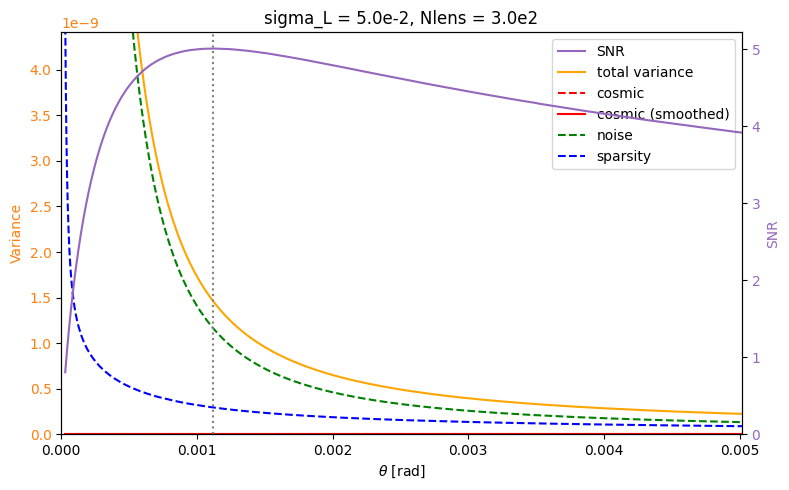

In [698]:
plotting('LEp')